In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from tqdm.autonotebook import tqdm
import pandas as pd
import numpy as np
import os
import shlex
import torch

if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from torch.utils.data import DataLoader
from BasisConvolution.util.hyperparameters import defaultHyperParameters, parseHyperParameters, finalizeHyperParameters
from BasisConvolution.util.arguments import parser
from BasisConvolution.sph.sphOps import sphOperationStates
from BasisConvolution.util.dataloader import datasetLoader, processFolder#, DataLoader
from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.hyperparameters import make_hash, toPandaDict
from BasisConvolution.util.network import buildModel, runInference

from BasisConvolution.util.augment import loadAugmentedBatch

In [11]:
hyperParameterDict = defaultHyperParameters()
hyperParameterDict['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'
# hyperParameterDict['device'] = 'cpu'
hyperParameterDict['augmentAngle'] = False
hyperParameterDict['augmentJitter'] = False
hyperParameterDict['maxRollOut'] = 0

In [12]:
datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'
basisFunction = 'ffourier'
basisTerms = 4
windowFunction = 'None'

args = parser.parse_args(shlex.split(f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1'))

hyperParameterDict = parseHyperParameters(args, None)
hyperParameterDict['device'] = 'cuda'
hyperParameterDict['iterations'] = 2**10

train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
print('Dataset has {} samples'.format(len(train_ds)))


print(train_ds.fileFormat)

# print(len(train_ds))
train_loader = DataLoader(train_ds, shuffle=True, batch_size = hyperParameterDict['batchSize']).batch_sampler
train_iter = iter(train_loader)

finalizeHyperParameters(hyperParameterDict, train_ds)

config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(123, train_ds, hyperParameterDict, unrollLength=0)


Dataset has 12600 samples
newFormat
Unroll length  1  exceeds maximum, limiting to 0


In [13]:
database = pd.DataFrame()

models = []

t = None
basisFunctions = ['ffourier', 'linear', 'ffourier_even', 'ffourier_odd', 'chebyshev']
for basisFunction in basisFunctions:
    # for basisTerms in [2,4,8]:
    for basisTerms in [4]:
        for windowFunction in ['None']:
            args = parser.parse_args(shlex.split(f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1'))

            hyperParameterDict = parseHyperParameters(args, None)
            hyperParameterDict['device'] = 'cuda'
            hyperParameterDict['iterations'] = 2**10
            hyperParameterDict['batchSize'] = 8
            # t.


            train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
            # print(len(train_ds))
            train_loader = DataLoader(train_ds, shuffle=True, batch_size = hyperParameterDict['batchSize']).batch_sampler
            train_iter = iter(train_loader)

            finalizeHyperParameters(hyperParameterDict, train_ds)

            if t is None:
                t = tqdm(range(hyperParameterDict['totalIterations']))
            t.reset( hyperParameterDict['totalIterations'])
            # t.n =
            t.set_description(f'{basisFunction} - {basisTerms} - {windowFunction}')

            # print(hyperParameterDict['progressLabel'])

            model, optimizer, scheduler = buildModel(hyperParameterDict, verbose = False)

            model = model.train()

            iterLosses = []
            iterPSNRs = []
            bdatas = []
            # bdata = next(train_iter)
            for i in (range(hyperParameterDict['totalIterations'])):
                try:
                    bdata = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    bdata = next(train_iter)
                bdatas.append(bdata)
                # print(bdata)
                configs, attributes, currentStates, priorStates, trajectoryStates = loadAugmentedBatch(bdata, train_ds, hyperParameterDict, unrollLength=0)
                # config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(bdata[0], train_ds, hyperParameterDict)

                optimizer.zero_grad()
                
                predictions = runInference(currentStates, configs, model, verbose = False)
                # print(predictions)
                if i % 100 == 0 or i < 10:  # Print first 10 iterations and every 100
                    pred_min = predictions[0].min().item()
                    pred_max = predictions[0].max().item()
                    print(f"[{basisFunction}] Iter {i:4d}: Pred[{pred_min:7.3f}, {pred_max:7.3f}]")
                    
                    # Check for explosion
                    if abs(pred_max) > 5.0:
                        print(f"   EXPLOSION in {basisFunction} at iteration {i}!")
                        print(f"   Range: [{pred_min:.1f}, {pred_max:.1f}]")

                gts = [traj[0]['fluid']['target'] for traj in trajectoryStates]

                losses = [torch.nn.functional.mse_loss(prediction, gt) for prediction, gt in zip(predictions, gts)]
                
                psnrs= [20 * torch.log10(gt.abs().max()) - 10 * torch.log10(loss) for gt, loss in zip(gts, losses)]
                loss = torch.stack(losses).mean()
                loss.backward()
                psnr = torch.stack(psnrs).mean()
                iterLosses.append([l.item() for l in losses])
                iterPSNRs.append([p.item() for p in psnrs])
                optimizer.step()
                t.set_description(f'{bdata} - {hyperParameterDict["progressLabel"]} - Loss: {loss.item():.4e}, PSNR: {psnr.item():.2f}')
                t.update()
                t.refresh()
            dataFrame = pd.DataFrame([toPandaDict(hyperParameterDict)] * len(bdatas))

            dataFrame['batches'] = bdatas
            for b in range(len(bdata)):
                dataFrame['losses_{}'.format(b)] = [iterLosses[i][b] for i in range(len(bdatas))]
                dataFrame['psnrs_{}'.format(b)] = [iterPSNRs[i][b] for i in range(len(bdatas))]

            dataFrame['losses'] = [np.mean(iterLosses[i]) for i in range(len(bdatas))]
            dataFrame['psnrs'] = [np.mean(iterPSNRs[i]) for i in range(len(bdatas))]
            dataFrame['iteration'] = np.arange(len(bdatas))

            database = pd.concat([database, dataFrame], ignore_index = True)
            models.append(model)


Unroll length  1  exceeds maximum, limiting to 0


  0%|          | 0/1024 [00:00<?, ?it/s]

[ffourier] Iter    0: Pred[ -0.028,   0.159]
[ffourier] Iter    1: Pred[ -0.006,   0.186]
[ffourier] Iter    2: Pred[  0.022,   0.219]
[ffourier] Iter    3: Pred[  0.057,   0.250]
[ffourier] Iter    4: Pred[  0.078,   0.270]
[ffourier] Iter    5: Pred[  0.088,   0.331]
[ffourier] Iter    6: Pred[  0.093,   0.421]
[ffourier] Iter    7: Pred[  0.107,   0.449]
[ffourier] Iter    8: Pred[  0.104,   0.515]
[ffourier] Iter    9: Pred[  0.125,   0.520]
[ffourier] Iter  100: Pred[  0.600,   1.944]
[ffourier] Iter  200: Pred[  0.800,   1.733]
[ffourier] Iter  300: Pred[  0.974,   1.590]
[ffourier] Iter  400: Pred[  1.009,   1.686]
[ffourier] Iter  500: Pred[  0.964,   1.757]
[ffourier] Iter  600: Pred[  1.015,   1.580]
[ffourier] Iter  700: Pred[  0.984,   1.738]
[ffourier] Iter  800: Pred[  0.995,   1.751]
[ffourier] Iter  900: Pred[  0.991,   1.694]
[ffourier] Iter 1000: Pred[  0.999,   1.495]
Unroll length  1  exceeds maximum, limiting to 0
[linear] Iter    0: Pred[ -0.032,   0.142]
[linear]

In [46]:
# 🔬 TRACE THE SOURCE OF YOUR WORKING HYPERPARAMETERS
print("🧪 TRACING SOURCE OF YOUR WORKING HYPERPARAMETERS")
print("="*60)

print(f"📊 YOUR CURRENT hyperParameterDict:")
print(f"   arch: '{hyperParameterDict.get('arch', 'MISSING')}'")
print(f"   layers: {hyperParameterDict.get('layers', 'MISSING')}")
print(f"   fcLayerMLPActive: {hyperParameterDict.get('fcLayerMLPActive', 'MISSING')}")

# Check if it came from defaultHyperParameters
from BasisConvolution.util.hyperparameters import defaultHyperParameters
default_params = defaultHyperParameters()
print(f"\n📊 DEFAULT HYPERPARAMETERS:")
print(f"   arch: '{default_params.get('arch', 'MISSING')}'")
print(f"   layers: {default_params.get('layers', 'MISSING')}")
print(f"   fcLayerMLPActive: {default_params.get('fcLayerMLPActive', 'MISSING')}")

# The arch ' 1 1 1' likely came from:
# 1. Manual setting in notebook
# 2. Different args parsing
# 3. Loaded from elsewhere
# 4. Default configuration

print(f"\n🔍 POSSIBLE SOURCES:")
print(f"   1. Manual setting: hyperParameterDict['arch'] = ' 1 1 1'")
print(f"   2. Different args: --arch ' 1 1 1' in some cell")
print(f"   3. Default config with FC layers enabled")
print(f"   4. Loaded from a previous training session")

print(f"\n💡 CORRECT UNDERSTANDING:")
print(f"   ✅ 1-parameter model IS the standard SFBC behavior")
print(f"   ✅ Your training works correctly with 1-parameter models")
print(f"   ❌ Save/load tries to create 8-parameter models (wrong!)")
print(f"   🔧 Fix: Save/load should preserve original architecture")

print(f"\n🎯 THE REAL SOLUTION:")
print(f"   Don't 'fix' hyperparameters in model_utils.py")
print(f"   Let 1-parameter models stay 1-parameter")
print(f"   Only apply fixes when actually needed")

🧪 TRACING SOURCE OF YOUR WORKING HYPERPARAMETERS
📊 YOUR CURRENT hyperParameterDict:
   arch: ' 1 1 1'
   layers: [1, 1, 1]
   fcLayerMLPActive: True

📊 DEFAULT HYPERPARAMETERS:
   arch: ''
   layers: MISSING
   fcLayerMLPActive: True

🔍 POSSIBLE SOURCES:
   1. Manual setting: hyperParameterDict['arch'] = ' 1 1 1'
   2. Different args: --arch ' 1 1 1' in some cell
   3. Default config with FC layers enabled
   4. Loaded from a previous training session

💡 CORRECT UNDERSTANDING:
   ✅ 1-parameter model IS the standard SFBC behavior
   ✅ Your training works correctly with 1-parameter models
   ❌ Save/load tries to create 8-parameter models (wrong!)
   🔧 Fix: Save/load should preserve original architecture

🎯 THE REAL SOLUTION:
   Don't 'fix' hyperparameters in model_utils.py
   Let 1-parameter models stay 1-parameter
   Only apply fixes when actually needed


In [15]:
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.network import runInference

In [16]:
basisTerms = database['basisTerms'].unique()
basisFunctions = database['basisFunctions'].unique()

print(basisTerms)
print(basisFunctions)

hues = sns.color_palette(n_colors = len(basisFunctions))
linestyles = ['--', '-', ':', '-.']

[4]
['ffourier' 'linear' 'ffourier_even' 'ffourier_odd' 'chebyshev']


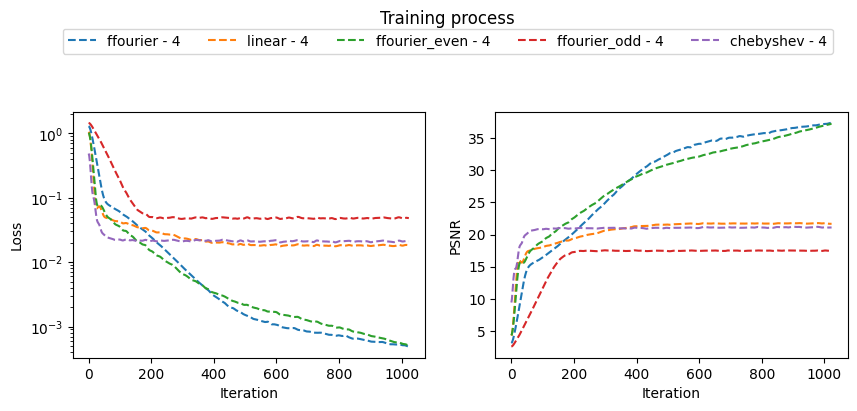

In [17]:
fig, axis = plt.subplots(1,2, figsize = (10,4), sharey = False, squeeze= False)

for i, basisFunction in enumerate(basisFunctions):
    for j, basisTerm in enumerate(basisTerms):
        subDatabase = database[(database['basisFunctions'] == basisFunction) & (database['basisTerms'] == basisTerm)]
        # subDatabase = subDatabase[subDatabase['dimension'] == 3]

        iters = subDatabase['iteration']
        losses = subDatabase['losses']
        psnrs = subDatabase['psnrs']

        losses = gaussian_filter1d(losses, sigma = 5)
        psnrs = gaussian_filter1d(psnrs, sigma = 5)

        axis[0,0].plot(iters, losses, label = f'{basisFunction} - {basisTerm}', color = hues[i], ls = linestyles[j])
        axis[0,1].plot(iters, psnrs, label = f'{basisFunction} - {basisTerm}', color = hues[i], ls = linestyles[j])

axis[0,0].set_yscale('log')
axis[0,0].set_xlabel('Iteration')
axis[0,0].set_ylabel('Loss')
# axis[0,0].legend(ncol = 2)

axis[0,1].set_xlabel('Iteration')
axis[0,1].set_ylabel('PSNR')

handles, labels = axis[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol = 5,bbox_to_anchor=(0.5, 0.95))

fig.suptitle('Training process')
fig.subplots_adjust(top = 0.725)# fig.bbox_inches = 'tight'

# fig.tight_layout()


In [18]:
#Save
if len(models) > 0:
    basisFunctions = ['ffourier', 'linear', 'ffourier_even', 'ffourier_odd', 'chebyshev']
    models_dict = {}
    
    for i, model in enumerate(models):
        if i < len(basisFunctions):
            basis_name = basisFunctions[i]
            if basis_name == 'ffourier':
                models_dict['ffourier'] = model
            elif basis_name == 'linear':
                models_dict['linear'] = model  
            elif basis_name == 'chebyshev':
                models_dict['chebyshev'] = model

from model_utils import save_model, save_hyperparameters

save_dir = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default"

# Save hyperparameters once
save_hyperparameters(hyperParameterDict, save_dir)

# Save models individually  
for basis_name, model in models_dict.items():
    save_model(model, basis_name, save_dir)

✅ Saved hyperparameters to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/hyperparameters.pth
✅ Saved ffourier model to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/ffourier_model.pth
✅ Saved linear model to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/linear_model.pth
✅ Saved chebyshev model to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/chebyshev_model.pth


In [5]:
from model_utils import load_models_for_visualization

save_dir = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default"

models_dict, hyperParameterDict = load_models_for_visualization(save_dir)

Found saved models: ['ffourier', 'linear', 'chebyshev']
✅ Loaded hyperparameters from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/hyperparameters.pth
✅ Loaded hyperparameters from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/hyperparameters.pth
✅ Created BasisNetwork for newer model: ffourier
✅ Loaded ffourier model from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/ffourier_model.pth
✅ Loaded hyperparameters from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/hyperparameters.pth
✅ Created BasisNetwork for newer model: linear
✅ Loaded linear model from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/linear_model.pth
✅ Loaded hyperparameters from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/default/hyperparameters.pt

In [19]:
test_datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/test'
test_ds = datasetLoader(processFolder(hyperParameterDict, test_datasetPath))
finalizeHyperParameters(hyperParameterDict, test_ds)

sample_idx = 0
config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(sample_idx, test_ds, hyperParameterDict)

if 'fluid' in currentState:
    fluid_positions = currentState['fluid']['positions']
    num_particles = fluid_positions.shape[0]
    spatial_dims = fluid_positions.shape[1]
    print(f'Number of particles per trajectory: {num_particles:,}')
    print(f'Spatial dimensions: {spatial_dims}D')

import os
import h5py

test_files = [f for f in os.listdir(test_datasetPath) if f.endswith('.hdf5')]
sample_file = os.path.join(test_datasetPath, test_files[0])

with h5py.File(sample_file, 'r') as f:
    if 'simulationExport' in f:
        timestep_groups = [key for key in f['simulationExport'].keys() if key.isdigit()]
        frames_per_trajectory = len(timestep_groups)

total_trajectories = len(test_files)
total_frames_combined = len(test_ds)

print(f'Test trajectories: {total_trajectories}')
print(f'Frames per trajectory: {frames_per_trajectory}')
print(f'Total frames in combined dataset: {total_frames_combined:,}')

import random
random_trajectory_idx = random.randint(0, total_trajectories - 1)
print(f'Selected test trajectory #{random_trajectory_idx}')

finalizeHyperParameters(hyperParameterDict, test_ds)

Unroll length  1  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Number of particles per trajectory: 2,500
Spatial dimensions: 2D
Test trajectories: 50
Frames per trajectory: 126
Total frames in combined dataset: 6,300
Selected test trajectory #40
Unroll length  1  exceeds maximum, limiting to 0


{'coordinateMapping': 'cartesian',
 'windowFunction': 'None',
 'liLoss': 'yes',
 'initialLR': 0.01,
 'finalLR': 0.0001,
 'lrStep': 10,
 'epochs': 1,
 'frameDistance': 0,
 'iterations': 1024,
 'dataDistance': 1,
 'cutoff': 1800,
 'dataLimit': -1,
 'seed': 42,
 'minUnroll': 2,
 'maxUnroll': 0,
 'historyLength': 0,
 'augmentAngle': False,
 'augmentJitter': False,
 'jitterAmount': 0.1,
 'networkSeed': 42,
 'network': 'default',
 'normalized': False,
 'adjustForFrameDistance': True,
 'weight_decay': 0,
 'input': './',
 'output': 'training',
 'loss': 'mse',
 'batchSize': 8,
 'fluidFeatures': 'constant:1',
 'boundaryFeatures': 'False',
 'boundary': False,
 'groundTruth': 'compute[rho]:constant:1/constant:rho0',
 'gtMode': 'abs',
 'verbose': False,
 'independent_dxdt': False,
 'unrollIncrement': 100,
 'networkType': 'w/o shift',
 'normalization': 'none',
 'skipLastShift': False,
 'shiftLoss': False,
 'activation': 'silu',
 'dataIndex': '',
 'dxdtLossScaling': 2,
 'exportPath': 'experiments',
 

In [20]:
from plotting_utils import *
frames_to_plot = [0, 30, 50, 100, 125]
figsize = (12, 12)
frame_idx = 12

 
print(f"Available models: {list(models_dict.keys())}")
print(f"Plotting frames: {frames_to_plot}")

Available models: ['ffourier', 'linear', 'chebyshev']
Plotting frames: [0, 30, 50, 100, 125]


Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0


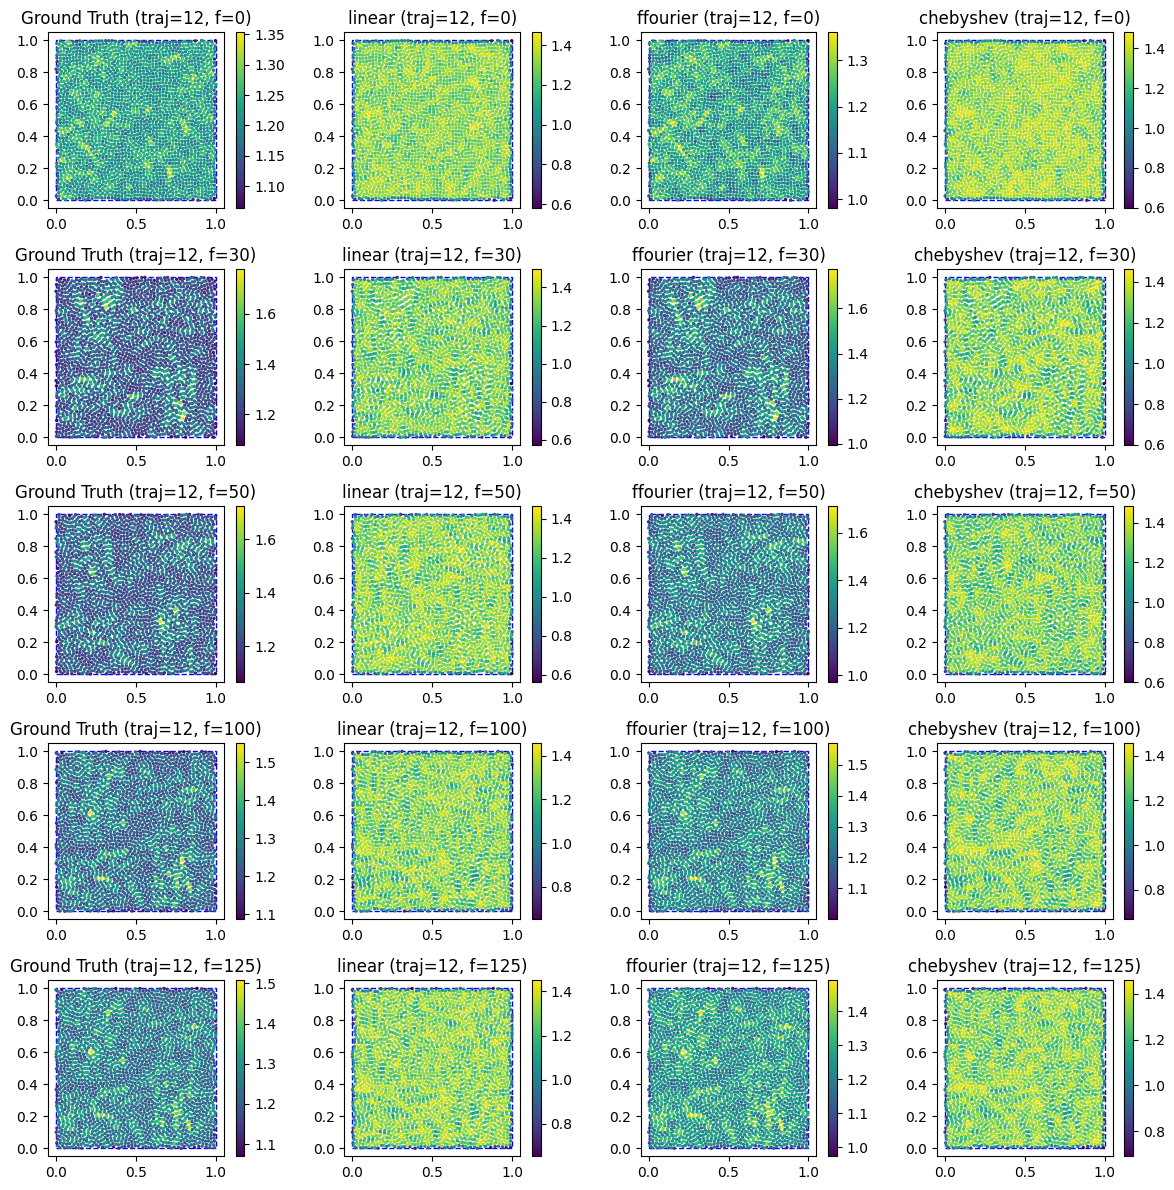

In [21]:
visualize_density_comparison_sph(models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    frames=frames_to_plot,
    trajectory_index=frame_idx,
    figsize=figsize
)

Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0


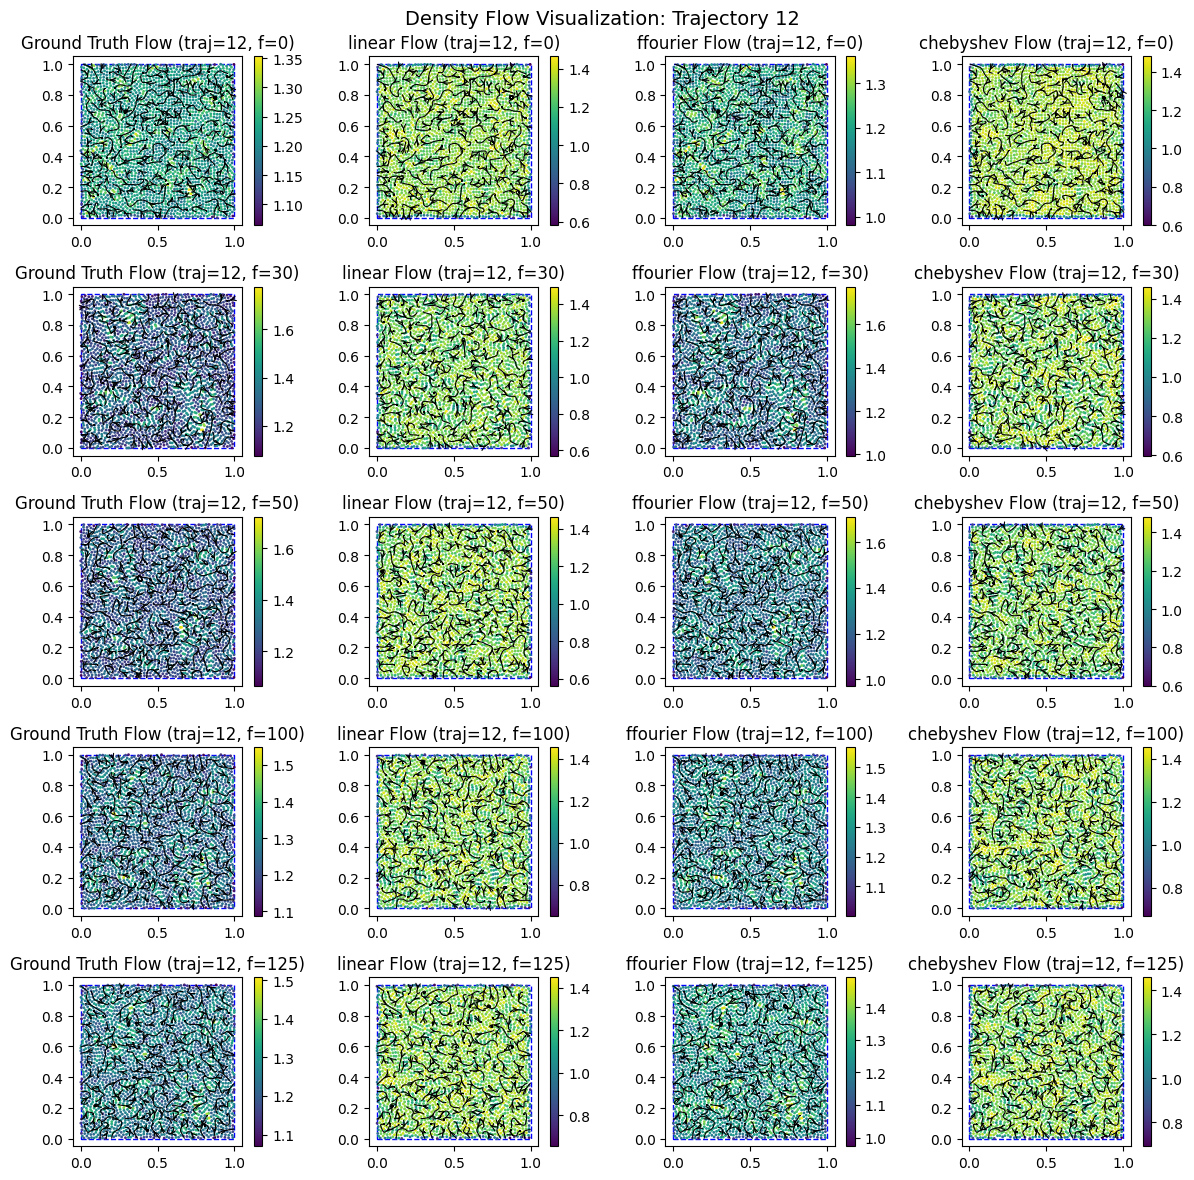

In [22]:
visualize_flow_comparison_sph(models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    frames=frames_to_plot,
    trajectory_index=frame_idx,
    figsize=figsize
)